# Introduction au Machine Learning

##### Importation des packages 

In [1]:
import dataset as ds
from scipy import ndimage
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
import collections
from sklearn.decomposition import PCA


##### On charge le dataset et on le découvre

In [2]:
digits = datasets.load_digits()
print(f"Colonnes du dataset :",digits.keys())
print(f"Targets :",digits.target_names)
print(f"Première images :\n",digits.images[0])
print(f"Nombre d'images :",digits.images.shape[0])

Colonnes du dataset : dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
Targets : [0 1 2 3 4 5 6 7 8 9]
Première images :
 [[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
Nombre d'images : 1797


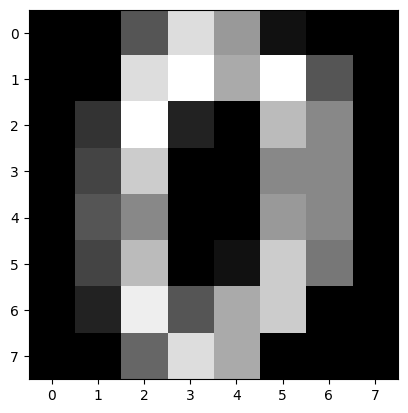

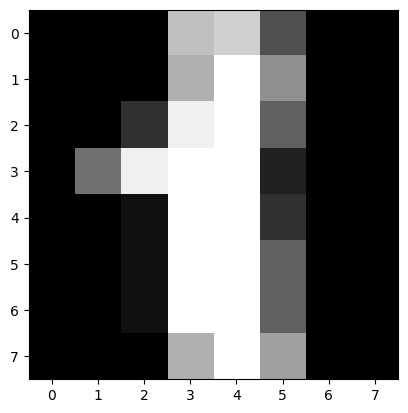

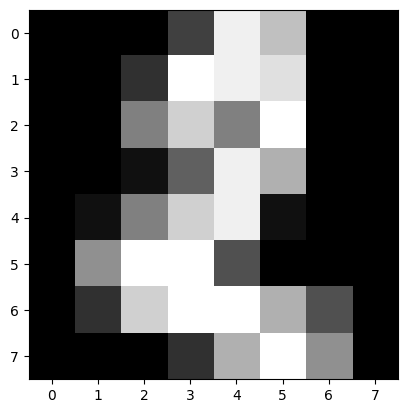

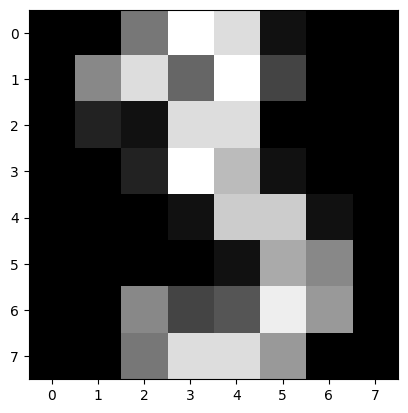

In [3]:
for i in range(4):
    plt.imshow(digits.images[i],cmap='gray')
    plt.show()

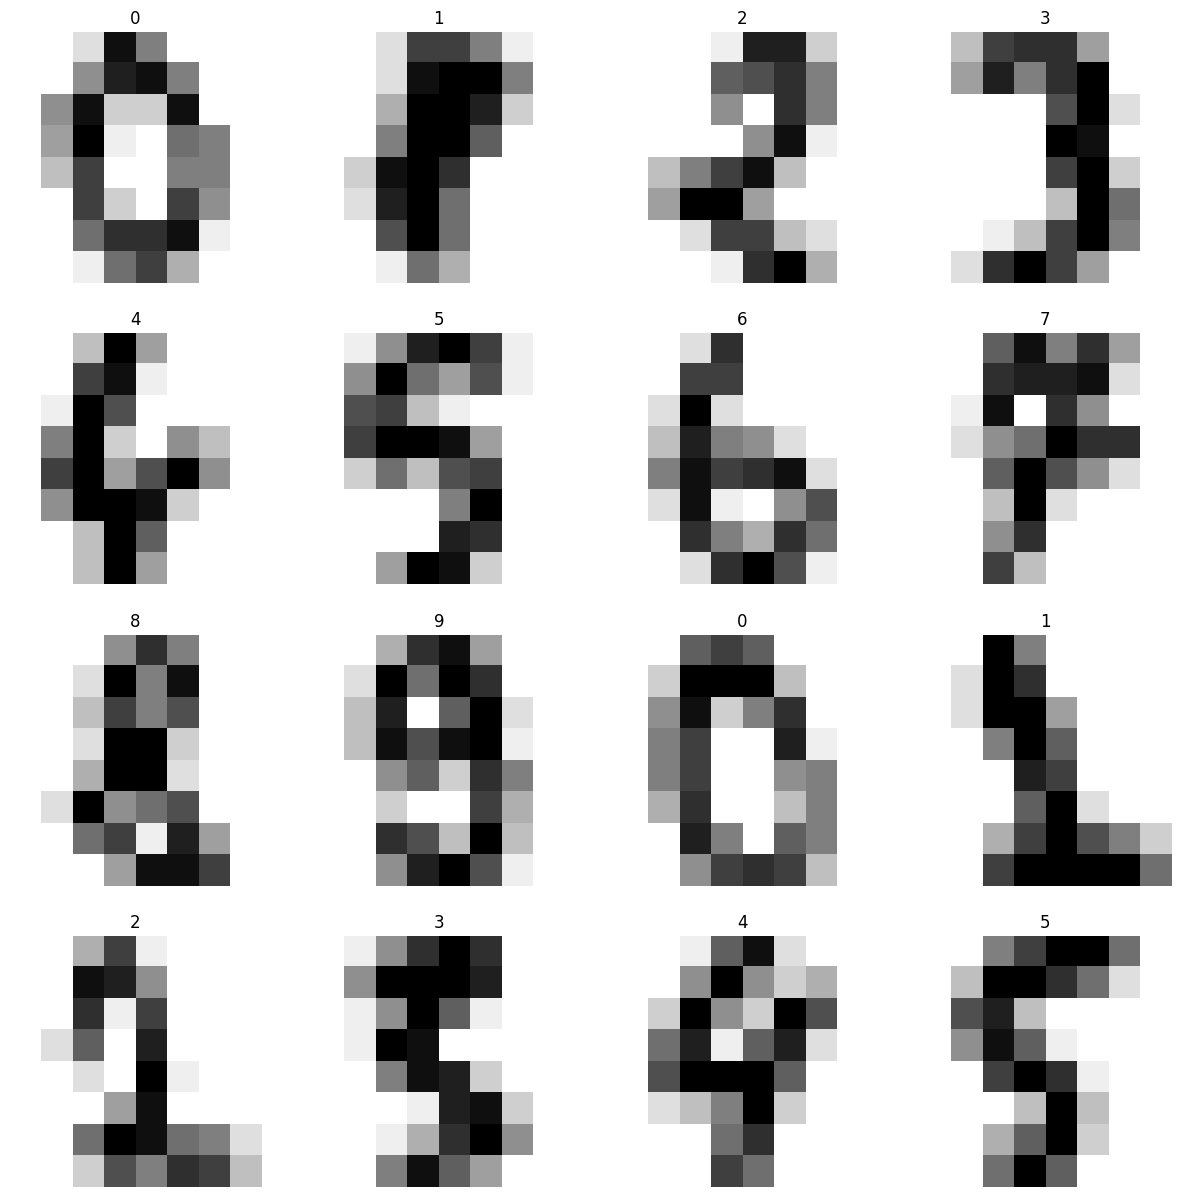

In [4]:
# Display at least one random sample par class (some repetitions of class... oh well)
def plot_multi(data, y):
    '''Plots 16 digits'''
    nplots = 16
    nb_classes = len(np.unique(y))
    cur_class = 0
    fig = plt.figure(figsize=(15,15))
    for j in range(nplots):
        plt.subplot(4,4,j+1)
        to_display_idx = np.random.choice(np.where(y == cur_class)[0])
        plt.imshow(data[to_display_idx].reshape((8,8)), cmap='binary')
        plt.title(cur_class)
        plt.axis('off')
        cur_class = (cur_class + 1) % nb_classes
    plt.show()


plot_multi(digits.data, digits.target)


In [5]:

# TODO: Create a feature matrix and a vector of labels
X = digits.data
y = digits.target_names

# Print dataset shape
print(f"Feature matrix shape: {X.shape}. Max value = {np.max(X)}, Min value = {np.min(X)}, Mean value = {np.mean(X)}")
print(f"Labels shape: {y.shape}")


Feature matrix shape: (1797, 64). Max value = 16.0, Min value = 0.0, Mean value = 4.884164579855314
Labels shape: (10,)


In [6]:
maxi = max(map(max,X))
F = X/maxi
# Print matrix shape
print(f"Feature matrix F shape: {F.shape}. Max value = {np.max(F)}, Min value = {np.min(F)}, Mean value = {np.mean(F)}")


Feature matrix F shape: (1797, 64). Max value = 1.0, Min value = 0.0, Mean value = 0.30526028624095713


In [7]:
F[0]

array([0.    , 0.    , 0.3125, 0.8125, 0.5625, 0.0625, 0.    , 0.    ,
       0.    , 0.    , 0.8125, 0.9375, 0.625 , 0.9375, 0.3125, 0.    ,
       0.    , 0.1875, 0.9375, 0.125 , 0.    , 0.6875, 0.5   , 0.    ,
       0.    , 0.25  , 0.75  , 0.    , 0.    , 0.5   , 0.5   , 0.    ,
       0.    , 0.3125, 0.5   , 0.    , 0.    , 0.5625, 0.5   , 0.    ,
       0.    , 0.25  , 0.6875, 0.    , 0.0625, 0.75  , 0.4375, 0.    ,
       0.    , 0.125 , 0.875 , 0.3125, 0.625 , 0.75  , 0.    , 0.    ,
       0.    , 0.    , 0.375 , 0.8125, 0.625 , 0.    , 0.    , 0.    ])

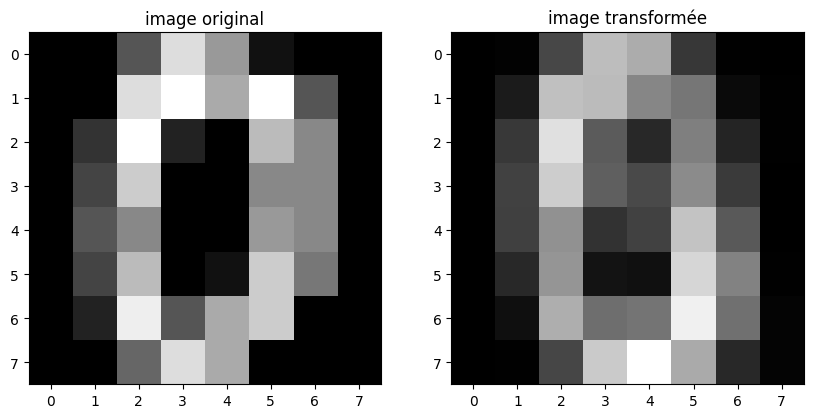

In [8]:

##########################################
## Dimensionality reduction
##########################################


### just an example to test, for various number of PCs
sample_index = 0
original_image = F[sample_index].reshape(8, 8)
# Stockage des reconstructions et des erreurs
reconstructed_images = []
errors = []
pca = PCA(n_components=2)
pca.fit(F)


compressed_sample = pca.transform(original_image.reshape(1, -1))


reconstructed_sample = pca.inverse_transform(compressed_sample).reshape(8, 8)
reconstructed_images.append(reconstructed_sample)

error = np.linalg.norm(original_image - reconstructed_sample)
errors.append(error)
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.title("image original")
plt.imshow(F[sample_index].reshape(8, 8), cmap='gray')  # Convertit en 8x8
plt.subplot(1,2,2)
plt.title("image transformée")
plt.imshow(reconstructed_images[0], cmap='gray')  # Convertit en 8x8
plt.show()
# TODO: Using the specific sample above, iterate the following:
# * Generate a PCA model with a certain value of principal components
# * Compute the approximation of the sample with this PCA model
# * Reconstruct a 64 dimensional vector from the reduced dimensional PCA space
# * Reshape the resulting approximation as an 8x8 matrix
# * Quantify the error in the approximation
# Finally: plot the original image and the 15 approximation on a 4x4 subfigure


[1.48905936e-01 1.36187712e-01 1.17945938e-01 8.40997942e-02
 5.78241466e-02 4.91691032e-02 4.31598701e-02 3.66137258e-02
 3.35324810e-02 3.07880621e-02 2.37234084e-02 2.27269657e-02
 1.82186331e-02 1.77385494e-02 1.46710109e-02 1.40971560e-02
 1.31858920e-02 1.24813782e-02 1.01771796e-02 9.05617439e-03
 8.89538461e-03 7.97123157e-03 7.67493255e-03 7.22903569e-03
 6.95888851e-03 5.96081458e-03 5.75614688e-03 5.15157582e-03
 4.89539777e-03 4.28887968e-03 3.73606048e-03 3.53274223e-03
 3.36683986e-03 3.28029851e-03 3.08320884e-03 2.93778629e-03
 2.56588609e-03 2.27742397e-03 2.22277922e-03 2.11430393e-03
 1.89909062e-03 1.58652907e-03 1.51159934e-03 1.40578764e-03
 1.16622290e-03 1.07492521e-03 9.64053065e-04 7.74630271e-04
 5.57211553e-04 4.04330693e-04 2.09916327e-04 8.24797098e-05
 5.25149980e-05 5.05243719e-05 3.29961363e-05 1.24365445e-05
 7.04827911e-06 3.01432139e-06 1.06230800e-06 5.50074587e-07
 3.42905702e-07 2.10911756e-18 0.00000000e+00 0.00000000e+00]
28


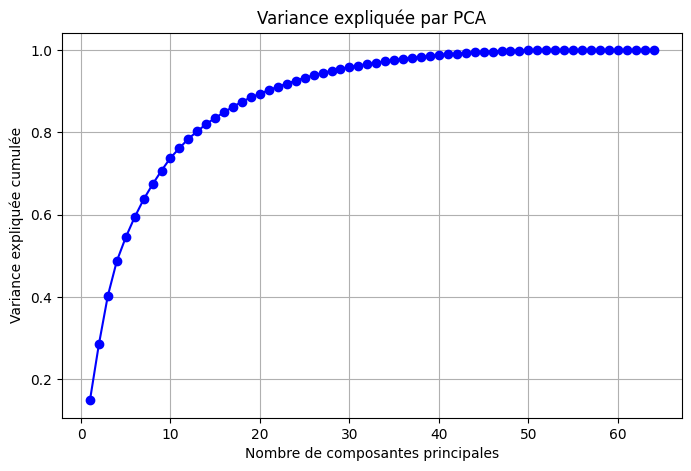

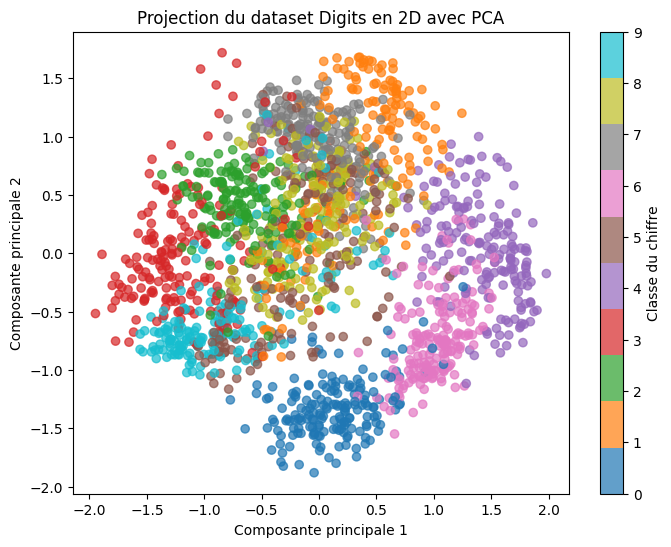

In [9]:
# 🔹 Application du PCA pour analyser la variance expliquée
pca = PCA(n_components=F.shape[1])  # On garde toutes les dimensions au début
pca.fit(F)
print(pca.explained_variance_ratio_)
explained_variance = np.cumsum(pca.explained_variance_ratio_)  
print(64-len(explained_variance[explained_variance>=0.95]))
plt.figure(figsize=(8, 5))
plt.plot(range(1, F.shape[1]+1), explained_variance, marker='o', linestyle='-', color='blue')
plt.xlabel("Nombre de composantes principales")
plt.ylabel("Variance expliquée cumulée")  
plt.title("Variance expliquée par PCA")
plt.grid()
plt.show()

pca_2d = PCA(n_components=2)
F_pca = pca_2d.fit_transform(F)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(F_pca[:, 0], F_pca[:, 1], c=digits.target, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label="Classe du chiffre")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Projection du dataset Digits en 2D avec PCA")
plt.show()

In [10]:

### TODO: Create a 20 dimensional PCA-based feature matrix

F_pca = PCA(n_components=20).fit_transform(F)

# Print reduced feature matrix shape
print(f"Feature matrix F_pca shape: {F_pca.shape}")




Feature matrix F_pca shape: (1797, 20)


In [11]:
def extract_zone_features(images):

    N = images.shape[0]  # Nombre d'images
    zones_means = np.zeros((N, 3))  # Stockage des moyennes des zones

    # Calcul des moyennes de zones pour chaque image
    zones_means[:, 0] = np.mean(images[:, 0:3, :], axis=(1, 2))  # Moyenne de la zone 1 (lignes 1-3)
    zones_means[:, 1] = np.mean(images[:, 3:5, :], axis=(1, 2))  # Moyenne de la zone 2 (lignes 4-5)
    zones_means[:, 2] = np.mean(images[:, 6:8, :], axis=(1, 2))  # Moyenne de la zone 3 (lignes 6-8)

    return zones_means

# Exemple d'application de la fonction
images = np.random.rand(1, 8, 8)  # 5 images aléatoires 8x8
F_zones = extract_zone_features(images)

# Affichage du tableau des caractéristiques
print("Matrice des moyennes de zones :")
print(F_zones)
print(f"Feature matrix F_zones shape: {F_zones.shape}")

Matrice des moyennes de zones :
[[0.28315249 0.4983175  0.52929141]]
Feature matrix F_zones shape: (1, 3)


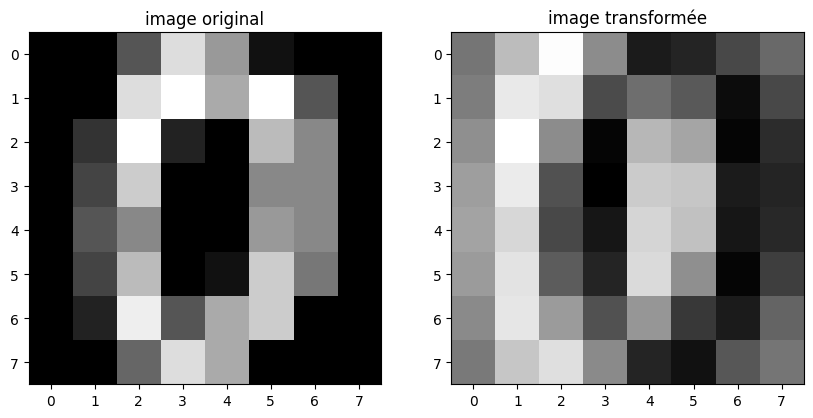

In [12]:
### Edge detection features

## TODO: Get used to the Sobel filter by applying it to an image and displaying both the original image 
# and the result of applying the Sobel filter side by side
original_image = F[sample_index].reshape(8, 8)
def sobel_affiche(image):
  plt.figure(figsize=(10, 5))
  plt.subplot(1,2,1)
  plt.title("image original")
  plt.imshow(image, cmap='gray')  # Convertit en 8x8
  plt.subplot(1,2,2)
  plt.title("image transformée")
  plt.imshow(ndimage.sobel(image), cmap='gray')  # Convertit en 8x8
  plt.show()

sobel_affiche(original_image)

In [13]:
# TODO: Compute the average edge intensity for each image and return it as an n by 1 array
def edge_mean(images):

  tab_mean= []
  for i in range(0,len(images)):
    tab_mean = np.append(tab_mean,np.mean(ndimage.sobel(images[i].reshape(8,8))))
  return tab_mean


F_edges = edge_mean(X)
print(np.mean(F_edges))

0.10774902615470228


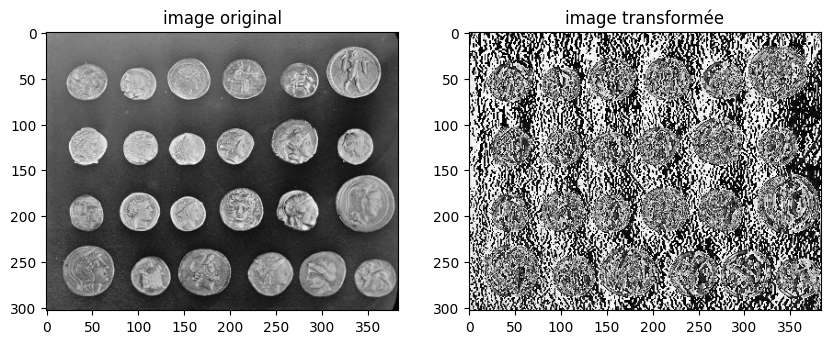

Moyenne de l'intensité des bords : 127.49


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from scipy import ndimage

image = data.coins()
image_norm = image / np.max(image)
sobel_edges = ndimage.sobel(image)

sobel_affiche(image)
mean_edge_intensity = np.mean(sobel_edges)
print(f"Moyenne de l'intensité des bords : {mean_edge_intensity:.2f}")

Division de donnée pour entrainenemnt

[162 163 160 165 161 164 163 160 157 162]
[16 19 17 18 20 18 18 19 17 18]


<BarContainer object of 10 artists>

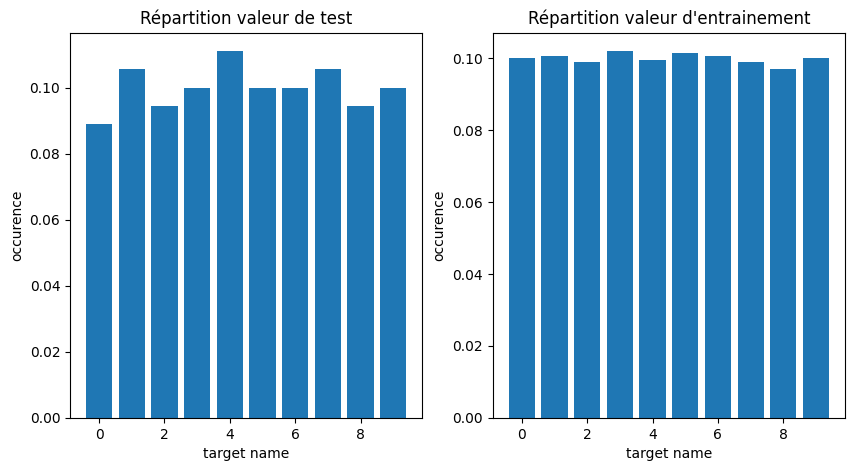

In [15]:
taille_tot = len(digits.data)
pourcentage_test = np.int64(np.floor(0.9*taille_tot))
digits_entrainement = digits.data[0:pourcentage_test]
digits_test = digits.data[pourcentage_test:taille_tot]
target = digits.target
repartition_targ_entr = np.bincount(target[0:pourcentage_test],minlength=10)
repartition_targ_test = np.bincount(target[pourcentage_test:taille_tot],minlength=10)
print(repartition_targ_entr)
print(repartition_targ_test)
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.title("Répartition valeur de test")
plt.xlabel("target name")
plt.ylabel("occurence")
plt.bar(digits.target_names,repartition_targ_test/np.sum(repartition_targ_test), )
plt.subplot(1,2,2)
plt.title("Répartition valeur d'entrainement")
plt.xlabel("target name")
plt.ylabel("occurence")
plt.bar(digits.target_names,repartition_targ_entr/np.sum(repartition_targ_entr))

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,recall_score,precision_score

def optim_dim(digits):
    pca = PCA(n_components=len(digits[0]))
    pca.fit(digits)
    explained_variance = np.cumsum(pca.explained_variance_ratio_)  
    return len(digits[0])-len(explained_variance[explained_variance>=0.95])
optim_pca = optim_dim(X)


pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Normalisation des données
    ('pca', PCA(n_components=optim_pca)),  # Réduction de dimension avec PCA
    ('classifier', SVC(kernel='linear'))  # Modèle de régression logistique
])
pipeline.fit(digits_entrainement,target[0:pourcentage_test])
y_pred = pipeline.predict(digits_entrainement)
print("Accuracy:",accuracy_score(target[0:pourcentage_test], y_pred))

print("Precision:", precision_score(target[0:pourcentage_test], y_pred, average="macro"))
print("Recall:", recall_score(target[0:pourcentage_test], y_pred, average="macro"))

Accuracy: 0.9987631416202845
Precision: 0.9987878787878788
Recall: 0.9987261146496815


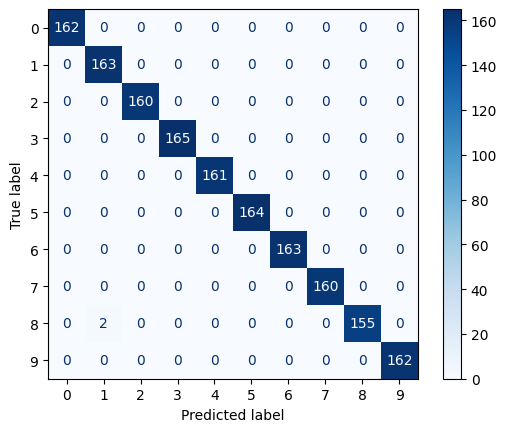

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 🔹 Calcul de la matrice de confusion
conf_matrix = confusion_matrix(target[0:pourcentage_test], y_pred)

# 🔹 Affichage graphique
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=digits.target_names)
disp.plot(cmap="Blues", values_format="d")